### Project Description

The goal of this project is to build a machine translation system using datasets containing translations in different languages. In this project, we use three different datasets containing Portuguese, Spanish, and French sentences, with English as the target language.

We build three separate translation models for Portuguese-to-English, Spanish-to-English, and French-to-English translation. Each model is trained to learn the relationship between the source language and English and generate the corresponding English translation.

### Objectives



*   **Data Preprocessing** : Importing and preparing the translation datasets for training.

*   **Tokenization** : Tokenizing the text data and converting the sentences into numerical tensors suitable for model training.

*   **Creating the Transformer Model** : Building a Transformer model using Positional Encoding, Encoder, and Decoder components.

*   **Training on Tiny Data** : Training the Transformer on a small dataset to verify that the model is learning and that the loss is decreasing.

*   **Training on Full Data** : Training the Transformer on the complete dataset after verifying its learning behavior on the small dataset.

*   **Creating the Translator** : Creating a Translator class to generate translations for Portuguese, Spanish, and French input text.

*   **Translation** : Testing the trained models by translating sentences from Portuguese, Spanish, and French into English.


### About the Dataset

There are three datasets used in this project. Each dataset contains sentences in a specific source language along with their corresponding English translations.



*   **Number of Dataset:** 3
*   **Datasets**

      1.   **df_en_pt:** Portuguese and English
      2.   **df_en_es:** Spanish and English
      3.   **df_en_fr:** French and English


### Import the Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers
from google.colab import files
# import tensorflow_datasets as tfds

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")

TensorFlow version: 2.20.0
GPU available: True


### Variables Assigning

In [ ]:
# Shared constants
VOCAB_SIZE   = 8000
BATCH_SIZE   = 64
MAX_LEN      = 40      # max source/target tokens (excl. [START]/[END])

# Tiny illustration model
TINY_LAYERS  = 1
TINY_D_MODEL = 32
TINY_HEADS   = 2
TINY_DFF     = 64
TINY_SAMPLES = 500
TINY_EPOCHS  = 30

# Full training model
FULL_LAYERS  = 2
FULL_D_MODEL = 128
FULL_HEADS   = 4
FULL_DFF     = 256
FULL_SAMPLES = 10000
FULL_EPOCHS  = 30

### Defining All Classes

In [ ]:
class PositionalEncoding(tf.keras.layers.Layer):
    def __init__(self, max_len, d_model, **kwargs):
        super().__init__(**kwargs)
        self.max_len = max_len
        self.d_model = d_model
        positions = np.arange(max_len)[:, np.newaxis]
        i_indices = np.arange(d_model // 2)[np.newaxis, :]
        angles = positions / np.power(10000.0, (2 * i_indices) / d_model)
        pe = np.zeros((max_len, d_model))
        pe[:, 0::2] = np.sin(angles)
        pe[:, 1::2] = np.cos(angles)
        self.pe = tf.cast(pe[np.newaxis, :, :], tf.float32)

    def call(self, x):
        return x + self.pe[:, :tf.shape(x)[1], :]

    def get_config(self):
        c = super().get_config()
        c.update({"max_len":self.max_len, "d_model":self.d_model})
        return c

class EncoderLayer(tf.keras.layers.Layer):
    def __init__(self, d_model, num_heads, dff, dropout_rate=0.1, **kwargs):
        super().__init__(**kwargs)
        self.d_model = d_model; self.num_heads = num_heads
        self.dff = dff; self.dropout_rate = dropout_rate
        self.mha = layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model // num_heads)
        self.ffn1 = layers.Dense(dff, activation='relu'); self.ffn2 = layers.Dense(d_model)
        self.norm1 = layers.LayerNormalization(epsilon=1e-6); self.norm2 = layers.LayerNormalization(epsilon=1e-6)
        self.drop1 = layers.Dropout(dropout_rate); self.drop2 = layers.Dropout(dropout_rate)
    def call(self, x, training=False, mask=None):
        a = self.drop1(self.mha(x, x, x, attention_mask=mask), training=training)
        x = self.norm1(x + a)
        f = self.drop2(self.ffn2(self.ffn1(x)), training=training)
        return self.norm2(x + f)
    def get_config(self):
        c = super().get_config(); c.update({"d_model": self.d_model, "num_heads": self.num_heads, "dff": self.dff, "dropout_rate": self.dropout_rate}); return c


class DecoderLayer(tf.keras.layers.Layer):
    def __init__(self, d_model, num_heads, dff, dropout_rate=0.1, **kwargs):
        super().__init__(**kwargs)
        self.d_model = d_model; self.num_heads = num_heads
        self.dff = dff; self.dropout_rate = dropout_rate
        self.mha1 = layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model // num_heads)
        self.mha2 = layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model // num_heads)
        self.ffn1 = layers.Dense(dff, activation='relu'); self.ffn2 = layers.Dense(d_model)
        self.norm1 = layers.LayerNormalization(epsilon=1e-6)
        self.norm2 = layers.LayerNormalization(epsilon=1e-6)
        self.norm3 = layers.LayerNormalization(epsilon=1e-6)
        self.drop1 = layers.Dropout(dropout_rate)
        self.drop2 = layers.Dropout(dropout_rate)
        self.drop3 = layers.Dropout(dropout_rate)
    def call(self, x, enc_output, training=False, look_ahead_mask=None, padding_mask=None):
        a1 = self.drop1(self.mha1(x, x, x, attention_mask=look_ahead_mask), training=training)
        x  = self.norm1(x + a1)
        a2 = self.drop2(self.mha2(x, enc_output, enc_output, attention_mask=padding_mask), training=training)
        x  = self.norm2(x + a2)
        f  = self.drop3(self.ffn2(self.ffn1(x)), training=training)
        return self.norm3(x + f)
    def get_config(self):
        c = super().get_config(); c.update({"d_model": self.d_model, "num_heads": self.num_heads, "dff": self.dff, "dropout_rate": self.dropout_rate}); return c


def create_padding_mask(seq):
    return tf.not_equal(seq, 0)[:, tf.newaxis, :]

def create_look_ahead_mask(size):
    rows = tf.cast(tf.range(size), tf.int32)
    cols = tf.cast(tf.range(size), tf.int32)
    return rows[:, tf.newaxis] >= cols[tf.newaxis, :]

def create_combined_mask(tar):
    seq_len = tf.shape(tar)[1]
    return create_look_ahead_mask(seq_len) & create_padding_mask(tar)


class Encoder(tf.keras.layers.Layer):
    def __init__(self, num_layers, d_model, num_heads, dff, vocab_size, max_len, dropout_rate=0.1, **kwargs):
        super().__init__(**kwargs)
        self._d_model = d_model; self._dropout_rate = dropout_rate
        self._num_layers = num_layers; self._num_heads = num_heads
        self._dff = dff; self._vocab_size = vocab_size; self._max_len = max_len
        self.embedding = layers.Embedding(vocab_size, d_model)
        self.pos_encoding = PositionalEncoding(max_len, d_model)
        self.enc_layers = [EncoderLayer(d_model, num_heads, dff, dropout_rate, name=f"enc_{i}") for i in range(num_layers)]
        self.dropout = layers.Dropout(dropout_rate)
    def call(self, x, training=False, mask=None):
        x = self.embedding(x) * tf.math.sqrt(tf.cast(self._d_model, tf.float32))
        x = self.dropout(self.pos_encoding(x), training=training)
        for layer in self.enc_layers:
            x = layer(x, training=training, mask=mask)
        return x
    def get_config(self):
        c = super().get_config(); c.update({"num_layers": self._num_layers, "d_model": self._d_model, "num_heads": self._num_heads, "dff": self._dff, "vocab_size": self._vocab_size, "max_len": self._max_len, "dropout_rate": self._dropout_rate}); return c


class Decoder(tf.keras.layers.Layer):
    def __init__(self, num_layers, d_model, num_heads, dff, vocab_size, max_len, dropout_rate=0.1, **kwargs):
        super().__init__(**kwargs)
        self._d_model = d_model; self._dropout_rate = dropout_rate
        self._num_layers = num_layers; self._num_heads = num_heads
        self._dff = dff; self._vocab_size = vocab_size; self._max_len = max_len
        self.embedding = layers.Embedding(vocab_size, d_model)
        self.pos_encoding = PositionalEncoding(max_len, d_model)
        self.dec_layers = [DecoderLayer(d_model, num_heads, dff, dropout_rate, name=f"dec_{i}") for i in range(num_layers)]
        self.dropout = layers.Dropout(dropout_rate)
    def call(self, x, enc_output, training=False, look_ahead_mask=None, padding_mask=None):
        x = self.embedding(x) * tf.math.sqrt(tf.cast(self._d_model, tf.float32))
        x = self.dropout(self.pos_encoding(x), training=training)
        for layer in self.dec_layers:
            x = layer(x, enc_output, training=training, look_ahead_mask=look_ahead_mask, padding_mask=padding_mask)
        return x
    def get_config(self):
        c = super().get_config(); c.update({"num_layers": self._num_layers, "d_model": self._d_model, "num_heads": self._num_heads, "dff": self._dff, "vocab_size": self._vocab_size, "max_len": self._max_len, "dropout_rate": self._dropout_rate}); return c


class Transformer(tf.keras.Model):
    def __init__(self, num_layers, d_model, num_heads, dff, input_vocab_size, target_vocab_size, max_len, dropout_rate=0.1, **kwargs):
        super().__init__(**kwargs)
        self.encoder = Encoder(num_layers, d_model, num_heads, dff, input_vocab_size, max_len, dropout_rate)
        self.decoder = Decoder(num_layers, d_model, num_heads, dff, target_vocab_size, max_len, dropout_rate)
        self.final_layer = layers.Dense(target_vocab_size, name="output_projection")
    def call(self, inputs, training=False):
        inp, tar = inputs
        enc_out = self.encoder(inp, training=training, mask=create_padding_mask(inp))
        dec_out = self.decoder(tar, enc_out, training=training,
                               look_ahead_mask=create_combined_mask(tar),
                               padding_mask=create_padding_mask(inp))
        return self.final_layer(dec_out)


print("All Transformer components defined.")

All Transformer components defined.


### Import Datasets

In [ ]:
df_en=pd.read_csv('ted_talks_en.csv')
df_pt=pd.read_csv('ted_talks_pt-br.csv')
df_es=pd.read_csv('ted_talks_es.csv')
df_fr=pd.read_csv('ted_talks_fr.csv')

In [ ]:
df=pd.merge(df_pt[['talk_id','transcript']],
        df_en[['talk_id','transcript']],
        on='talk_id',
        suffixes=('_pt','_en'))

In [ ]:
df_en_es = pd.merge(df_es[['talk_id','transcript']],
        df_en[['talk_id','transcript']],
        on='talk_id',
        suffixes=('_es','_en'))

In [ ]:
df_en_fr = pd.merge(df_fr[['talk_id','transcript']],
        df_en[['talk_id','transcript']],
        on='talk_id',
        suffixes=('_fr','_en'))

In [ ]:
pt_texts = df['transcript_pt'].astype(str).tolist()
en_texts = df['transcript_en'].astype(str).tolist()

In [ ]:
en_texts = df_en_es['transcript_en'].astype(str).tolist()
es_texts = df_en_es['transcript_es'].astype(str).tolist()

In [ ]:
fr_texts = df_en_fr['transcript_fr'].astype(str).tolist()
en_texts = df_en_fr['transcript_en'].astype(str).tolist()

### Converting Sentences into Tokens

In [ ]:
en_with_tokens=['[START] ' + s + ' [END]' for s in en_texts]

pt_vec = tf.keras.layers.TextVectorization(
    max_tokens=VOCAB_SIZE,
    output_mode='int',
    output_sequence_length=MAX_LEN
)
en_vec = tf.keras.layers.TextVectorization(
    max_tokens=VOCAB_SIZE,
    output_mode='int',
    output_sequence_length=MAX_LEN+2
)
pt_vec.adapt(pt_texts)
en_vec.adapt(en_with_tokens)

pt_tokens = pt_vec(pt_texts).numpy()
en_tokens = en_vec(en_with_tokens).numpy()

print(f"PT tokens shape: {pt_tokens.shape}")
print(f"EN tokens shape: {en_tokens.shape}")
print(f"PT vocab size: {len(pt_vec.get_vocabulary())}")
print(f"EN vocab size: {len(en_vec.get_vocabulary())}")

en_vocab = en_vec.get_vocabulary()

START_ID = en_vocab.index('start')
END_ID = en_vocab.index('end')

print(f"[START] token id: {START_ID}")
print(f"[END] token id: {END_ID}")

PT tokens shape: (3975, 40)
EN tokens shape: (3975, 42)
PT vocab size: 8000
EN vocab size: 8000
[START] token id: 125
[END] token id: 132


In [ ]:
# en_with_tokens=['[START] ' + s + ' [END]' for s in en_texts]

es_vec = tf.keras.layers.TextVectorization(
    max_tokens=VOCAB_SIZE,
    output_mode='int',
    output_sequence_length=MAX_LEN
)
en_vec = tf.keras.layers.TextVectorization(
    max_tokens=VOCAB_SIZE,
    output_mode='int',
    output_sequence_length=MAX_LEN+2
)
es_vec.adapt(es_texts)
en_vec.adapt(en_with_tokens)

es_tokens = es_vec(es_texts).numpy()
en_tokens = en_vec(en_with_tokens).numpy()

print(f"ES tokens shape: {es_tokens.shape}")
print(f"EN tokens shape: {en_tokens.shape}")
print(f"ES vocab size: {len(es_vec.get_vocabulary())}")
print(f"EN vocab size: {len(en_vec.get_vocabulary())}")

en_vocab = en_vec.get_vocabulary()

START_ID = en_vocab.index('start')
END_ID = en_vocab.index('end')

print(f"[START] token id: {START_ID}")
print(f"[END] token id: {END_ID}")

ES tokens shape: (3915, 40)
EN tokens shape: (3915, 42)
ES vocab size: 8000
EN vocab size: 8000
[START] token id: 125
[END] token id: 132


In [ ]:
en_with_tokens=['[START] ' + s + ' [END]' for s in en_texts]

fr_vec = tf.keras.layers.TextVectorization(
    max_tokens=VOCAB_SIZE,
    output_mode='int',
    output_sequence_length=MAX_LEN
)
en_vec = tf.keras.layers.TextVectorization(
    max_tokens=VOCAB_SIZE,
    output_mode='int',
    output_sequence_length=MAX_LEN+2
)
fr_vec.adapt(fr_texts)
en_vec.adapt(en_with_tokens)

fr_tokens = fr_vec(fr_texts).numpy()
en_tokens = en_vec(en_with_tokens).numpy()

print(f"PT tokens shape: {fr_tokens.shape}")
print(f"EN tokens shape: {en_tokens.shape}")
print(f"PT vocab size: {len(fr_vec.get_vocabulary())}")
print(f"EN vocab size: {len(en_vec.get_vocabulary())}")

en_vocab = en_vec.get_vocabulary()

START_ID = en_vocab.index('start')
END_ID = en_vocab.index('end')

print(f"[START] token id: {START_ID}")
print(f"[END] token id: {END_ID}")

PT tokens shape: (3860, 40)
EN tokens shape: (3860, 42)
PT vocab size: 8000
EN vocab size: 8000
[START] token id: 125
[END] token id: 132


In [ ]:
# Training helper — split into teacher-forcing pairs and batch
def make_dataset(inp_toks, en_toks):
    ds = tf.data.Dataset.from_tensor_slices((inp_toks, en_toks))
    return ds.shuffle(len(inp_toks), seed=42).batch(BATCH_SIZE)

# Shared training loop
def run_training(transformer, dataset, epochs, label=''):
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)
    loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)

    @tf.function
    def train_step(inp, tar):
        tar_inp = tar[:, :-1]       # decoder input  — drop last token
        tar_real = tar[:, 1:]       # target labels  — drop [START]
        with tf.GradientTape() as tape:
            predictions = transformer([inp, tar_inp], training=True)
            loss = loss_fn(tar_real, predictions)

        grads = tape.gradient(loss, transformer.trainable_variables)
        optimizer.apply_gradients(zip(grads, transformer.trainable_variables))
        return loss

    losses=[]
    for epoch in range(epochs):
        total, n = 0.0, 0
        for inp_b, tar_b in dataset:
            total += float(train_step(inp_b, tar_b))
            n += 1
        avg = total / n
        losses.append(avg)
        print(f"  [{label}] Epoch {epoch + 1}/{epochs}  loss: {avg:.4f}")
    return losses

### Training On Tiny Data

In [ ]:
# tiny_ds_pt = make_dataset(pt_tokens[:TINY_SAMPLES], en_tokens[:TINY_SAMPLES])
# tiny_ds_es = make_dataset(es_tokens[:TINY_SAMPLES], en_tokens[:TINY_SAMPLES])
tiny_ds_fr = make_dataset(fr_tokens[:TINY_SAMPLES], en_tokens[:TINY_SAMPLES])

tiny_transformer = Transformer(
    num_layers=TINY_LAYERS, d_model=TINY_D_MODEL,
    num_heads=TINY_HEADS,   dff=TINY_DFF,
    input_vocab_size=VOCAB_SIZE, target_vocab_size=VOCAB_SIZE,
    max_len=MAX_LEN + 2, name="TinyTransformer"
)

# Build with a dummy forward pass to enable summary
_ = tiny_transformer(
    [tf.zeros((1, MAX_LEN), tf.int32), tf.zeros((1, MAX_LEN + 1), tf.int32)]
)
tiny_transformer.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'enc_0' (of type EncoderLayer) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'encoder' (of type Encoder) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


Model: "TinyTransformer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder (Encoder)               │ ?                      │       264,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder (Decoder)               │ ?                      │       268,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_projection (Dense)       │ (1, 41, 8000)          │       264,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 797,376 (3.04 MB)

 Trainable params: 797,376 (3.04 MB)

 Non-trainable params: 0 (0.00 B)

Tiny model training (500 samples, 30 epochs)



/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'enc_0' (of type EncoderLayer) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'encoder' (of type Encoder) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


  [Tiny] Epoch 1/30  loss: 8.8694
  [Tiny] Epoch 2/30  loss: 8.5348
  [Tiny] Epoch 3/30  loss: 8.1659
  [Tiny] Epoch 4/30  loss: 7.8045
  [Tiny] Epoch 5/30  loss: 7.4648
  [Tiny] Epoch 6/30  loss: 7.1537
  [Tiny] Epoch 7/30  loss: 6.8779
  [Tiny] Epoch 8/30  loss: 6.6408
  [Tiny] Epoch 9/30  loss: 6.4459
  [Tiny] Epoch 10/30  loss: 6.2867
  [Tiny] Epoch 11/30  loss: 6.1655
  [Tiny] Epoch 12/30  loss: 6.0738
  [Tiny] Epoch 13/30  loss: 6.0098
  [Tiny] Epoch 14/30  loss: 5.9648
  [Tiny] Epoch 15/30  loss: 5.9302
  [Tiny] Epoch 16/30  loss: 5.8955
  [Tiny] Epoch 17/30  loss: 5.8673
  [Tiny] Epoch 18/30  loss: 5.8361
  [Tiny] Epoch 19/30  loss: 5.7997
  [Tiny] Epoch 20/30  loss: 5.7589
  [Tiny] Epoch 21/30  loss: 5.7158
  [Tiny] Epoch 22/30  loss: 5.6706
  [Tiny] Epoch 23/30  loss: 5.6208
  [Tiny] Epoch 24/30  loss: 5.5698
  [Tiny] Epoch 25/30  loss: 5.5163
  [Tiny] Epoch 26/30  loss: 5.4653
  [Tiny] Epoch 27/30  loss: 5.4067
  [Tiny] Epoch 28/30  loss: 5.3465
  [Tiny] Epoch 29/30  loss: 5

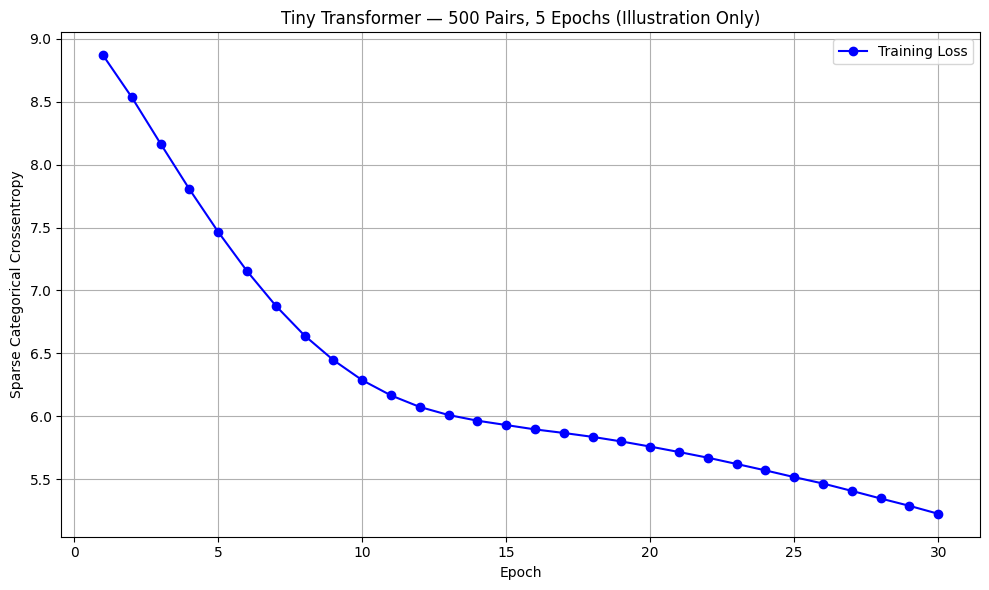

Final loss: 5.2248


In [ ]:
print("Tiny model training (500 samples, 30 epochs)\n")
# tiny_losses = run_training(tiny_transformer, tiny_ds_pt, TINY_EPOCHS, label='Tiny')
# tiny_losses = run_training(tiny_transformer, tiny_ds_es, TINY_EPOCHS, label='Tiny')
tiny_losses = run_training(tiny_transformer, tiny_ds_fr, TINY_EPOCHS, label='Tiny')

plt.figure(figsize=(10, 6))
plt.plot(range(1, TINY_EPOCHS + 1), tiny_losses,
         color='blue', marker='o', label='Training Loss')
plt.title('Tiny Transformer — 500 Pairs, 5 Epochs (Illustration Only)')
plt.xlabel('Epoch')
plt.ylabel('Sparse Categorical Crossentropy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
print(f"Final loss: {tiny_losses[-1]:.4f}")

### Training On Full Datasets

In [ ]:
# full_ds_pt = make_dataset(pt_tokens, en_tokens)
# full_ds_es = make_dataset(es_tokens, en_tokens)
full_ds_fr = make_dataset(fr_tokens, en_tokens)

full_transformer = Transformer(
    num_layers=FULL_LAYERS, d_model=FULL_D_MODEL,
    num_heads=FULL_HEADS,   dff=FULL_DFF,
    input_vocab_size=VOCAB_SIZE, target_vocab_size=VOCAB_SIZE,
    max_len=MAX_LEN + 2, name="FullTransformer"
)

_ = full_transformer(
    [tf.zeros((1, MAX_LEN), tf.int32), tf.zeros((1, MAX_LEN + 1), tf.int32)]
)
full_transformer.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'enc_0' (of type EncoderLayer) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'enc_1' (of type EncoderLayer) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'encoder_1' (of type Encoder) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


Model: "FullTransformer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_1 (Encoder)             │ ?                      │     1,288,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_1 (Decoder)             │ ?                      │     1,421,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_projection (Dense)       │ (1, 41, 8000)          │     1,032,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,742,528 (14.28 MB)

 Trainable params: 3,742,528 (14.28 MB)

 Non-trainable params: 0 (0.00 B)

Full model training (10k samples, 30 epochs — GPU recommended)

  [Full] Epoch 1/30  loss: 6.7781
  [Full] Epoch 2/30  loss: 5.7713
  [Full] Epoch 3/30  loss: 5.2922
  [Full] Epoch 4/30  loss: 4.9721
  [Full] Epoch 5/30  loss: 4.6652
  [Full] Epoch 6/30  loss: 4.3725
  [Full] Epoch 7/30  loss: 4.0933
  [Full] Epoch 8/30  loss: 3.8188
  [Full] Epoch 9/30  loss: 3.5659
  [Full] Epoch 10/30  loss: 3.3163
  [Full] Epoch 11/30  loss: 3.0798
  [Full] Epoch 12/30  loss: 2.8642
  [Full] Epoch 13/30  loss: 2.6536
  [Full] Epoch 14/30  loss: 2.4646
  [Full] Epoch 15/30  loss: 2.2853
  [Full] Epoch 16/30  loss: 2.1139
  [Full] Epoch 17/30  loss: 1.9643
  [Full] Epoch 18/30  loss: 1.8229
  [Full] Epoch 19/30  loss: 1.7009
  [Full] Epoch 20/30  loss: 1.5827
  [Full] Epoch 21/30  loss: 1.4756
  [Full] Epoch 22/30  loss: 1.3792
  [Full] Epoch 23/30  loss: 1.2952
  [Full] Epoch 24/30  loss: 1.2102
  [Full] Epoch 25/30  loss: 1.1396
  [Full] Epoch 26/30  loss: 1.0720
  [Full] Epoch 27/30  loss: 1.0181


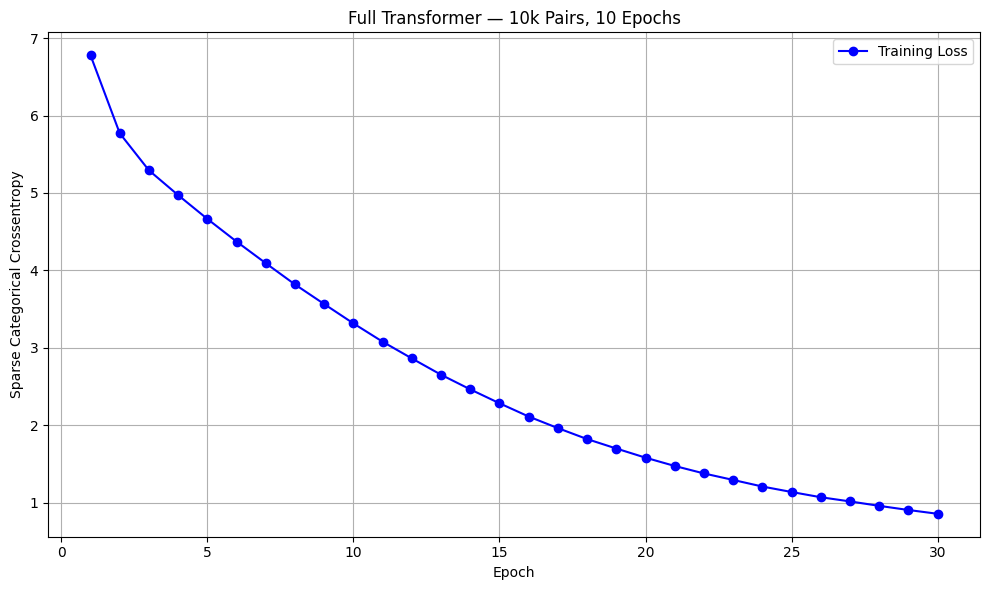

Final loss: 0.8583


In [ ]:
print("Full model training (10k samples, 30 epochs — GPU recommended)\n")
# full_losses = run_training(full_transformer, full_ds_pt, FULL_EPOCHS, label='Full')
# full_losses = run_training(full_transformer, full_ds_es, FULL_EPOCHS, label='Full')
full_losses = run_training(full_transformer, full_ds_fr, FULL_EPOCHS, label='Full')

plt.figure(figsize=(10, 6))
plt.plot(range(1, FULL_EPOCHS + 1), full_losses,
         color='blue', marker='o', label='Training Loss')
plt.title('Full Transformer — 10k Pairs, 10 Epochs')
plt.xlabel('Epoch')
plt.ylabel('Sparse Categorical Crossentropy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
print(f"Final loss: {full_losses[-1]:.4f}")

### Build Our Translator Class

In [ ]:
class Translator:

    "Autoregressive greedy decoder for a trained Transformer"
    def __init__(self, transformer, inp_vec, en_vec, max_len=MAX_LEN):
        self.transformer = transformer
        self.inp_vec = inp_vec
        self.max_len = max_len

        vocab = en_vec.get_vocabulary()
        self.start_id = vocab.index('start')
        self.end_id = vocab.index('end')
        self.id_to_word = {i: w for i, w in enumerate(vocab)}

    def translate(self, sentence):
        # Step 1: tokenise source sentence → (1, MAX_LEN)
        inp_tokens = self.inp_vec([sentence])

        # Step 2: initialise decoder with [START]
        output = tf.constant([[self.start_id]], dtype=tf.int32)    # (1, 1)

        for _ in range(self.max_len):
            # Step 3: forward pass — logits shape (1, cur_len, vocab_size)
            predictions = self.transformer([inp_tokens, output], training=False)
            next_logits = predictions[:, -1, :]   # last position only
            next_id = int(tf.argmax(next_logits, axis=-1)[0])     # greedy argmax

            # Step 4: stop at [END]
            if next_id == self.end_id:
                break

            # Step 5: grow the output sequence
            output = tf.concat(
                [output, tf.constant([[next_id]], dtype=tf.int32)], axis=-1
            )

        # Step 6: decode token IDs to words (skip [START])
        token_ids = output.numpy()[0][1:]
        words = [
            self.id_to_word.get(i, '')
            for i in token_ids
            if self.id_to_word.get(i, '') not in ('', '[UNK]', '[START]', '[END]')
        ]
        return ' '.join(words)


# translator = Translator(full_transformer, pt_vec, en_vec)
# translator = Translator(full_transformer, es_vec, en_vec)
translator = Translator(full_transformer, fr_vec, en_vec)
print('Translator ready.')

Translator ready.


### Converting French Into English

In [ ]:
# Test sentences in French.

test_sentences = [
    "C'est mon premier jour.",
    "La technologie change le monde.",
    "Merci pour votre attention.",
    "Le problème est très difficile.",
]

print("=" * 60)
for fr_sentence in test_sentences:
    translation = translator.translate(fr_sentence)
    print(f"FR: {fr_sentence}")
    print(f"EN: {translation}")
    print("-" * 60)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'enc_0' (of type EncoderLayer) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'enc_1' (of type EncoderLayer) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'encoder_1' (of type Encoder) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


PT: C'est mon premier jour.
EN: its first day my first day its first day along the first day its first day i record my first day its my first day its my first day its first day its first day back day back day i
------------------------------------------------------------
PT: La technologie change le monde.
EN: technology it makes awesome technology the worlds most language it language the sound language the language the language the sound world feet the path the world fashion movies the key the world it king is it language the
------------------------------------------------------------
PT: Merci pour votre attention.
EN: thank you for your your humanity to your reading by your dna by asking anyone thousands by starting by neuroscience thousands by 40 by 40 thanks butterflies by regular folks thanks to your neuroscience through your attention to your attention
------------------------------------------------------------
PT: Le problème est très difficile.
EN: the problem is very diffic

### Converting Spanish Into English

In [ ]:
# Test sentences in Spanish.

test_sentences = [
    "Este es mi primer día.",
    "La tecnología está cambiando el mundo.",
    "Gracias por su atención.",
    "El problema es muy difícil.",
]

print("=" * 60)
for es_sentence in test_sentences:
    translation = translator.translate(es_sentence)
    print(f"ES: {es_sentence}")
    print(f"EN: {translation}")
    print("-" * 60)

PT: Este es mi primer día.
EN: this is my first day my first day my first day its first day my first day its right day this is my first day this is my first day its first day my first day day days after all
------------------------------------------------------------
PT: La tecnología está cambiando el mundo.
EN: technology is changing the world changing world changing world changing the world changing the world technology changing the world technology its changing the world technology changing the world its really complicated world changing the world regardless of world changing our
------------------------------------------------------------
PT: Gracias por su atención.
EN: thank you for your attention attention attention attention for your attention thank attention for her attention — for your attention thanks attention — laughter thank attention — his attention to her attention everything attention for your attention for your attention
----------------------------------------------

### Converting Portuguese Into English

In [ ]:
# Test sentences in Portuguese.

test_sentences = [
    "este é o meu primeiro dia.",
    "a tecnologia está mudando o mundo.",
    "obrigado pela sua atenção.",
    "o problema é muito difícil.",
]

print("=" * 60)
for pt_sentence in test_sentences:
    translation = translator.translate(pt_sentence)
    print(f"PT: {pt_sentence}")
    print(f"EN: {translation}")
    print("-" * 60)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'enc_0' (of type EncoderLayer) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'enc_1' (of type EncoderLayer) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'encoder_2' (of type Encoder) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


PT: este é o meu primeiro dia.
EN: this or this or this this or this this room have or this or
------------------------------------------------------------
PT: a tecnologia está mudando o mundo.
EN: is or world there are the world or or on the world to its going to be limited to world — or world to world its world to
------------------------------------------------------------
PT: obrigado pela sua atenção.
EN: 
------------------------------------------------------------
PT: o problema é muito difícil.
EN: planetary problem or hard difficult enough difficult questions or difficult answers or difficult difficult difficult or difficult but or difficult questions or difficult questions too hard to answer hard times does hard education be hard to realize
------------------------------------------------------------
